In [28]:
import sklearn
from sklearn.datasets import fetch_california_housing, load_diabetes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')

In [29]:
# EDA Regression

# classification dataset
housing_df = fetch_california_housing(as_frame=True).frame
housing_df['target_house_value'] = fetch_california_housing().target
housing_df = housing_df.drop('MedHouseVal', axis=1)
diabetes_df = load_diabetes(as_frame=True).frame
diabetes_df['target'] = load_diabetes().target

print ("\nAnalysing the data for california housing....")
print (f"The rows and columns for california housing is {housing_df.shape}")
print (housing_df.info())
print (housing_df.describe().T)
print (f"\nColumns with missing data\n{housing_df.isnull().sum()}")
print ("======================\n\n")

print ("\nAnalysing the data for diabetes....")
print (f"The rows and columns for california housing is {diabetes_df.shape}")
print (diabetes_df.info())
print (diabetes_df.describe().T)
print (f"\nColumns with missing data\n{diabetes_df.isnull().sum()}")


Analysing the data for california housing....
The rows and columns for california housing is (20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MedInc              20640 non-null  float64
 1   HouseAge            20640 non-null  float64
 2   AveRooms            20640 non-null  float64
 3   AveBedrms           20640 non-null  float64
 4   Population          20640 non-null  float64
 5   AveOccup            20640 non-null  float64
 6   Latitude            20640 non-null  float64
 7   Longitude           20640 non-null  float64
 8   target_house_value  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
                      count         mean          std         min         25%  \
MedInc              20640.0     3.870671     1.899822    0.499900    2.563400   
HouseAge            20640.0    28.639486 

In [30]:
corr_housing_df = housing_df.corr()
print(corr_housing_df["target_house_value"].sort_values(ascending=False))

target_house_value    1.000000
MedInc                0.688075
AveRooms              0.151948
HouseAge              0.105623
AveOccup             -0.023737
Population           -0.024650
Longitude            -0.045967
AveBedrms            -0.046701
Latitude             -0.144160
Name: target_house_value, dtype: float64


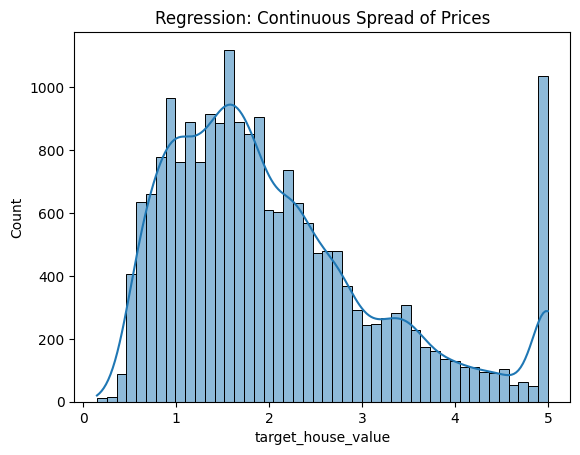

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using your California Housing target (Prices)
sns.histplot(housing_df['target_house_value'], kde=True)
plt.title("Regression: Continuous Spread of Prices")
plt.show()

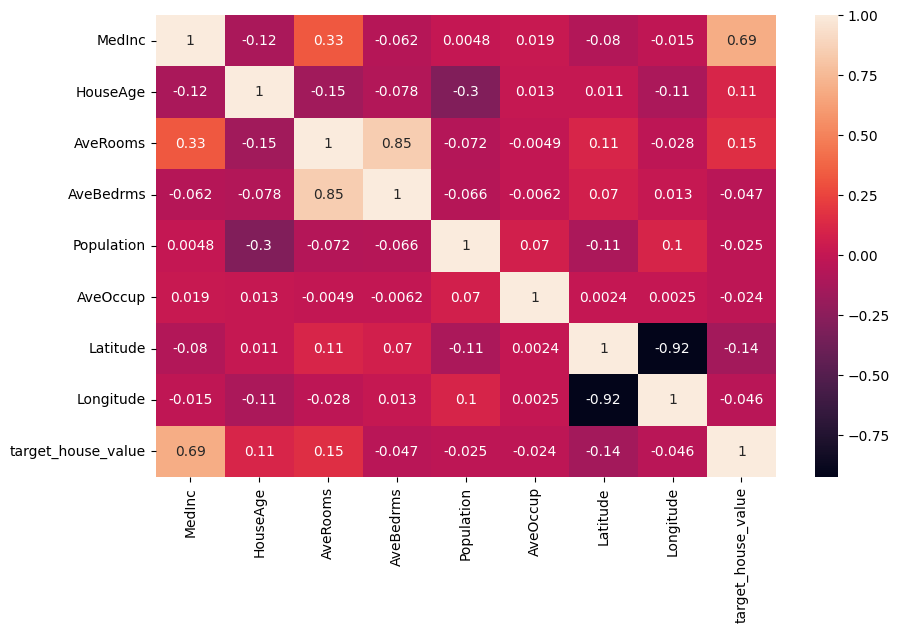

In [33]:
# checking the co-relation between columns as for linear regression the columns
# should not be linearly dependent
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(corr_housing_df, annot=True)
plt.show()

In [34]:
corr_matrix = corr_housing_df.abs()

# get only upper half of the matrix
upper = corr_matrix.where(
    ~np.tril(np.ones(corr_matrix.shape)).astype(bool)
)
upper
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

print(f"Identified Columns that need to be dropped {to_drop}")
finalised_housing_df = housing_df.drop(columns=to_drop)
print (f"{to_drop} columns removed from dataframe")
finalised_housing_df.head()

Identified Columns that need to be dropped ['AveBedrms', 'Longitude']
['AveBedrms', 'Longitude'] columns removed from dataframe


,MedInc,HouseAge,AveRooms,Population,AveOccup,Latitude,target_house_value
0,8.3252,41.0,6.984127,322.0,2.555556,37.88,4.526
1,8.3014,21.0,6.238137,2401.0,2.109842,37.86,3.585
2,7.2574,52.0,8.288136,496.0,2.802260,37.85,3.521
3,5.6431,52.0,5.817352,558.0,2.547945,37.85,3.413
4,3.8462,52.0,6.281853,565.0,2.181467,37.85,3.422


In [37]:
# Drop the target column to isolate your features
X = finalised_housing_df.drop('target_house_value', axis=1)

# Isolate the target column
y = finalised_housing_df['target_house_value']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining on {X_train.shape[0]} samples, testing on {X_test.shape[0]} samples.")


Training on 16512 samples, testing on 4128 samples.


,MedInc,HouseAge,AveRooms,Population,AveOccup,Latitude
0,8.3252,41.0,6.984127,322.0,2.555556,37.88
1,8.3014,21.0,6.238137,2401.0,2.109842,37.86
2,7.2574,52.0,8.288136,496.0,2.802260,37.85
3,5.6431,52.0,5.817352,558.0,2.547945,37.85
4,3.8462,52.0,6.281853,565.0,2.181467,37.85
...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,845.0,2.560606,39.48
20636,2.5568,18.0,6.114035,356.0,3.122807,39.49
20637,1.7000,17.0,5.205543,1007.0,2.325635,39.43
20638,1.8672,18.0,5.329513,741.0,2.123209,39.43


In [38]:
# train the model

from sklearn.linear_model import LinearRegression

# Initialize and train
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [40]:
## model evaluation

from sklearn.metrics import r2_score, mean_squared_error

# Make predictions on the unseen test data
predictions = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)

print("=== Model Evaluation ===")
print(f"R-squared Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")

=== Model Evaluation ===
R-squared Score: 0.5060
Mean Squared Error: 0.6474


In [ ]:
## for diabetes to be done